In [1]:
import torch
import torch.nn as nn
import numpy as np
import shap
import os

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import matplotlib.pyplot as plt
import io

c:\Users\jeffr\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: DLL load failed while importing rdBase: An Application Control policy has blocked this file.

In [29]:
import torch.nn as nn

class ToxicityModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 12)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [30]:
model_path = r"D:\Drug_Toxicity_AI\models\multilabel_model.pth"

model = ToxicityModel()
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()

print("Model loaded ✅")

Model loaded ✅


C:\Users\jeffr\AppData\Local\Temp\ipykernel_5840\4290587427.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=tor

In [31]:
X_train = np.load(r"D:\Drug_Toxicity_AI\data\features\X_train.npy")

background = torch.tensor(X_train[:50], dtype=torch.float32)

In [32]:
explainer = shap.Explainer(
    lambda x: model(torch.tensor(x, dtype=torch.float32)).detach().numpy(),
    X_train[:100]
)

print("SHAP (safe) ready ✅")

SHAP (safe) ready ✅


In [33]:
tox_cols = [
    'NR-AR','NR-AR-LBD','NR-AhR','NR-Aromatase',
    'NR-ER','NR-ER-LBD','NR-PPAR-gamma',
    'SR-ARE','SR-ATAD5','SR-HSE','SR-MMP','SR-p53'
]

In [34]:
BASE = r"D:\Drug_Toxicity_AI"

In [35]:
def full_pipeline(smiles):

    import torch
    import numpy as np
    from rdkit import Chem
    from rdkit.Chem import AllChem
    from rdkit.Chem.Draw import rdMolDraw2D
    import os
    from PIL import Image
    import matplotlib.pyplot as plt
    import io

    # -----------------------------
    # 1. SMILES → Molecule
    # -----------------------------
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "Invalid SMILES ❌"

    bit_info = {}

    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 512, bitInfo=bit_info)
    x = np.array(fp)
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0)

    # -----------------------------
    # 2. Prediction
    # -----------------------------
    with torch.no_grad():
        output = model(x_tensor).numpy()[0]

    probs = torch.sigmoid(torch.tensor(output)).numpy()

    max_prob = float(np.max(probs))
    label_idx = int(np.argmax(probs))

    toxicity_score = round(min(max_prob, 0.98), 3)
    prediction = "Toxic ⚠️" if toxicity_score > 0.5 else "Non-Toxic ✅"

    predicted_label = tox_cols[label_idx]

    # -----------------------------
    # 3. SHAP
    # -----------------------------
    shap_vals = explainer(
        x.reshape(1, -1),
        max_evals=1100
    )
    shap_vals = shap_vals.values[0]

    if len(shap_vals.shape) == 2:
        shap_combined = np.abs(shap_vals[:, label_idx])
    else:
        shap_combined = np.abs(shap_vals)

    shap_combined = np.array(shap_combined).flatten()

    # -----------------------------
    # 4. Map → Atoms
    # -----------------------------
    atom_scores = {i: 0.0 for i in range(mol.GetNumAtoms())}

    for bit in range(len(shap_combined)):
        if bit in bit_info:
            for atom_idx, _ in bit_info[bit]:
                if atom_idx < mol.GetNumAtoms():
                    atom_scores[atom_idx] += float(shap_combined[bit])

    max_score = max(atom_scores.values()) if atom_scores else 0

    important_atoms = [
        i for i, v in atom_scores.items()
        if v > 0.2 * max_score
    ]

    atom_symbols = list(set([
        mol.GetAtomWithIdx(i).GetSymbol()
        for i in important_atoms
    ])) if important_atoms else []

    # -----------------------------
    # 5. SAVE + DISPLAY IMAGES 🔥
    # -----------------------------
    save_dir = os.path.join(BASE, "outputs", "single_predictions")
    os.makedirs(save_dir, exist_ok=True)

    # ORIGINAL
    d = rdMolDraw2D.MolDraw2DCairo(400, 400)
    d.DrawMolecule(mol)
    d.FinishDrawing()
    img1_bytes = d.GetDrawingText()

    with open(os.path.join(save_dir, "original.png"), "wb") as f:
        f.write(img1_bytes)

    # HIGHLIGHTED
    colors = {i: (1, 0.5, 0.5) for i in important_atoms}

    d2 = rdMolDraw2D.MolDraw2DCairo(400, 400)
    d2.DrawMolecule(mol, highlightAtoms=important_atoms, highlightAtomColors=colors)
    d2.FinishDrawing()
    img2_bytes = d2.GetDrawingText()

    with open(os.path.join(save_dir, "highlighted.png"), "wb") as f:
        f.write(img2_bytes)

    # DISPLAY 🔥
    img1 = Image.open(io.BytesIO(img1_bytes))
    img2 = Image.open(io.BytesIO(img2_bytes))

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title("Original Molecule")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title("Highlighted (Important Atoms)")
    plt.axis('off')

    plt.show()

    # -----------------------------
    # 6. Functional Groups
    # -----------------------------
    functional_groups = []

    if mol.HasSubstructMatch(Chem.MolFromSmarts("[OX2H]")):
        functional_groups.append("hydroxyl")

    if mol.HasSubstructMatch(Chem.MolFromSmarts("[NX3;H2,H1]")):
        functional_groups.append("amine")

    if mol.HasSubstructMatch(Chem.MolFromSmarts("a1aaaaa1")):
        functional_groups.append("aromatic ring")

    if mol.HasSubstructMatch(Chem.MolFromSmarts("S(=O)(=O)N")):
        functional_groups.append("sulfonamide")

    # -----------------------------
    # 7. Explanation
    # -----------------------------
    if prediction == "Toxic ⚠️":
        explanation = (
            f"The molecule is predicted toxic mainly for '{predicted_label}'. "
            f"The highlighted atoms {atom_symbols} contribute most. "
            f"Functional groups {functional_groups} influence toxicity."
        )
    else:
        explanation = (
            f"The molecule is predicted non-toxic due to absence of strong reactive groups. "
            f"Detected groups {functional_groups} are relatively stable."
        )

    # -----------------------------
    # 8. FINAL OUTPUT
    # -----------------------------
    return f"""
SMILES: {smiles}

Prediction: {prediction}
Confidence: {toxicity_score}

Main Label: {predicted_label}

Important Atoms: {atom_symbols}
Functional Groups: {functional_groups}

Explanation:
{explanation}

Images saved at:
{save_dir}
"""

[16:43:01] DEPRECATION WARNING: please use MorganGenerator


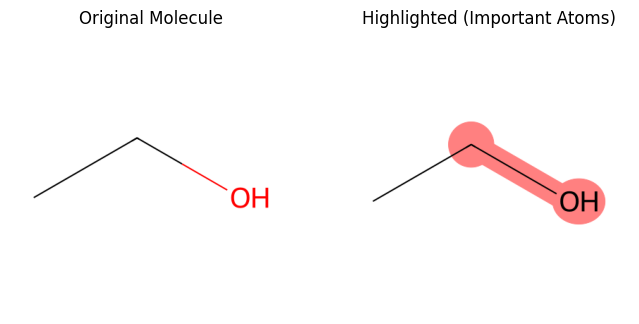


SMILES: CCO

Prediction: Non-Toxic ✅
Confidence: 0.054

Main Label: NR-ER

Important Atoms: ['O', 'C']
Functional Groups: ['hydroxyl']

Explanation:
The molecule is predicted non-toxic due to absence of strong reactive groups. Detected groups ['hydroxyl'] are relatively stable.

Images saved at:
D:\Drug_Toxicity_AI\outputs\single_predictions



In [ ]:
print(full_pipeline("CCO"))